In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from google.colab import drive, userdata
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

Libraries imported successfully!
TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
DATASET_DIR = '/content/drive/MyDrive/Project_2k26/rice_disease_dataset'
CLASS_NAMES = ['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro']
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = len(CLASS_NAMES)
EPOCHS      = 30
LR          = 0.001

print(f"Dataset path  : {DATASET_DIR}")
print(f"Classes       : {CLASS_NAMES}")
print(f"Image size    : {IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning rate : {LR}")
print(f"Total classes : {NUM_CLASSES}")

Dataset path  : /content/drive/MyDrive/Project_2k26/rice_disease_dataset
Classes       : ['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro']
Image size    : (224, 224)
Batch size    : 32
Epochs        : 30
Learning rate : 0.001
Total classes : 5


In [4]:
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    validation_split   = 0.2,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    vertical_flip      = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    seed        = SEED,
    shuffle     = True
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    seed        = SEED,
    shuffle     = False
)

print("Generators created successfully!")
print(f"Training samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")

Found 5778 images belonging to 5 classes.
Found 1442 images belonging to 5 classes.
Generators created successfully!
Training samples   : 5778
Validation samples : 1442


In [5]:
labels  = train_gen.classes
weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels),
    y            = labels
)
class_weights = dict(enumerate(weights))

print("Class weights:")
print("=" * 40)
for idx, w in class_weights.items():
    print(f"  {CLASS_NAMES[idx]:<22} : {w:.4f}")
print("=" * 40)

Class weights:
  Bacterialblight        : 0.9114
  Blast                  : 1.0031
  Brownspot              : 1.0318
  Healthy                : 0.9703
  Tungro                 : 1.1037


In [6]:
# Load MobileNetV2 base — pretrained on ImageNet, without top layer
base_model = MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights     = 'imagenet'
)

# Freeze base model layers initially
base_model.trainable = False

# Build custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer = Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Model built successfully!")
print(f"Total layers       : {len(model.layers)}")
print(f"Trainable layers   : {len([l for l in model.layers if l.trainable])}")
print(f"Non-trainable      : {len([l for l in model.layers if not l.trainable])}")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully!
Total layers       : 161
Trainable layers   : 7
Non-trainable      : 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
save_dir = '/content/drive/MyDrive/Project_2k26/Phase3_outputs/'
os.makedirs(save_dir, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath          = f'{save_dir}best_model.keras',
        monitor           = 'val_accuracy',
        save_best_only    = True,
        mode              = 'max',
        verbose           = 1
    ),
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 7,
        restore_best_weights = True,
        verbose   = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print("Callbacks set successfully!")
print(f"Model will be saved to : {save_dir}best_model.keras")

Callbacks set successfully!
Model will be saved to : /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras


In [8]:
print("=" * 50)
print("PHASE 1 TRAINING — Frozen Base Model")
print("=" * 50)

history1 = model.fit(
    train_gen,
    epochs          = 15,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1
)

print("=" * 50)
print("Phase 1 Training Complete!")
print(f"Best val accuracy : {max(history1.history['val_accuracy']):.4f}")
print("=" * 50)

PHASE 1 TRAINING — Frozen Base Model
Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7730 - loss: 0.6016
Epoch 1: val_accuracy improved from None to 0.96949, saving model to /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 1472s 8s/step - accuracy: 0.8628 - loss: 0.3730 - val_accuracy: 0.9695 - val_loss: 0.1082 - learning_rate: 0.0010
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.9427 - loss: 0.1628
Epoch 2: val_accuracy improved from 0.96949 to 0.98058, saving model to /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 107s 589ms/step - accuracy: 0.9462 - loss: 0.1552 - val_accuracy: 0.9806 - val_loss: 0.0465 - learning_rate: 0.0010
Epoch 3/15
181/181 

In [9]:
print("=" * 50)
print("PHASE 2 TRAINING — Fine-Tuning Top Layers")
print("=" * 50)

# Unfreeze top 30 layers of base model
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print(f"Trainable layers after unfreezing : {len([l for l in model.layers if l.trainable])}")

history2 = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1
)

print("=" * 50)
print("Phase 2 Fine-Tuning Complete!")
print(f"Best val accuracy : {max(history2.history['val_accuracy']):.4f}")
print("=" * 50)

PHASE 2 TRAINING — Fine-Tuning Top Layers
Trainable layers after unfreezing : 37
Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9490 - loss: 0.1717
Epoch 1: val_accuracy did not improve from 1.00000
181/181 ━━━━━━━━━━━━━━━━━━━━ 145s 696ms/step - accuracy: 0.9553 - loss: 0.1488 - val_accuracy: 0.9958 - val_loss: 0.0087 - learning_rate: 1.0000e-05
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9619 - loss: 0.1166
Epoch 2: val_accuracy did not improve from 1.00000
181/181 ━━━━━━━━━━━━━━━━━━━━ 109s 602ms/step - accuracy: 0.9621 - loss: 0.1134 - val_accuracy: 0.9972 - val_loss: 0.0094 - learning_rate: 1.0000e-05
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9722 - loss: 0.0922
Epoch 3: val_accuracy did not improve from 1.00000

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
181/181 ━━━━━━━━━━━━━━━━━━━━ 116s 642ms/step - accuracy: 0.9728 - loss: 0.0908 - val_accuracy: 0.9945 - val_loss: 0.0155 - lea

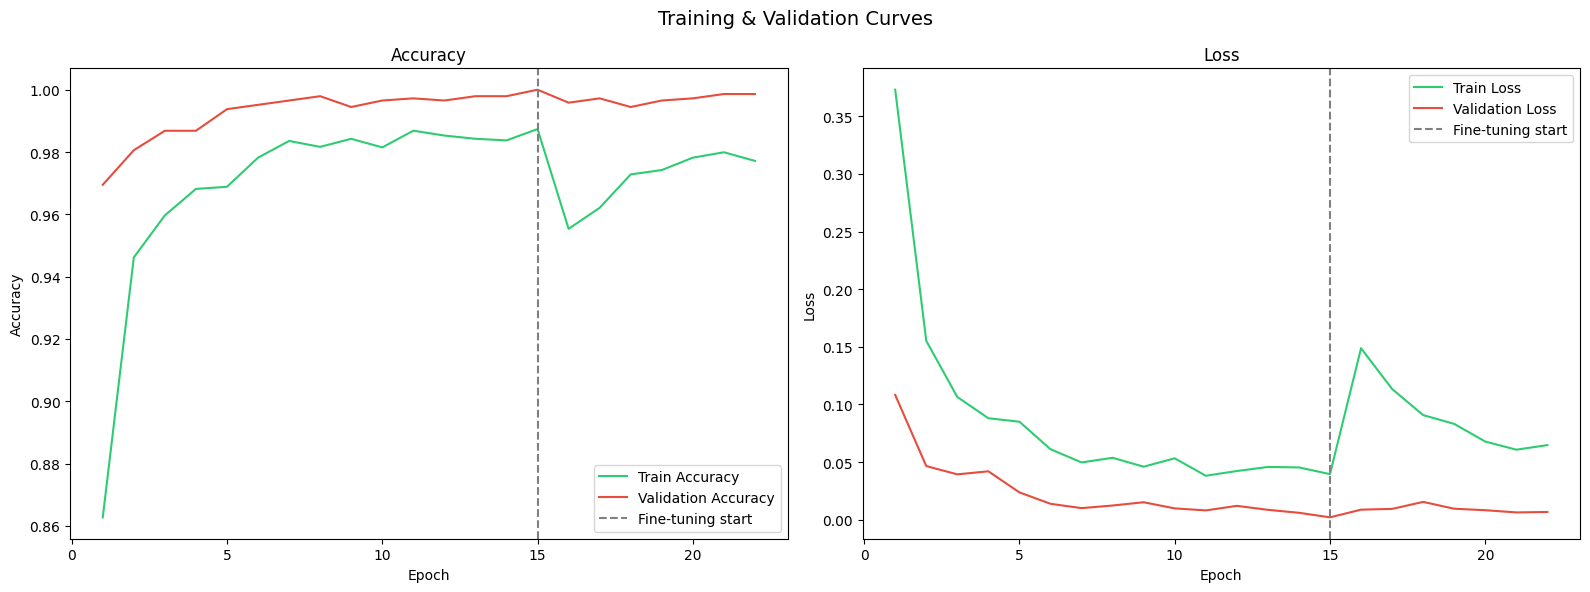

Training curves saved!


In [10]:
# Combine both training histories
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training & Validation Curves', fontsize=14)

# Accuracy plot
axes[0].plot(epochs_range, acc,     label='Train Accuracy',      color='#2ecc71')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', color='#e74c3c')
axes[0].axvline(x=15, color='gray', linestyle='--', label='Fine-tuning start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(epochs_range, loss,     label='Train Loss',      color='#2ecc71')
axes[1].plot(epochs_range, val_loss, label='Validation Loss', color='#e74c3c')
axes[1].axvline(x=15, color='gray', linestyle='--', label='Fine-tuning start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.savefig(f'{save_dir}training_curves.png', dpi=150)
plt.show()
print("Training curves saved!")

In [11]:
print("Evaluating best model on validation set...")

val_gen.reset()
loss, accuracy = model.evaluate(val_gen, verbose=1)

print("=" * 45)
print("       FINAL MODEL RESULTS")
print("=" * 45)
print(f"  Validation Loss     : {loss:.4f}")
print(f"  Validation Accuracy : {accuracy * 100:.2f}%")
print("=" * 45)

Evaluating best model on validation set...
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9958 - loss: 0.0087
       FINAL MODEL RESULTS
  Validation Loss     : 0.0087
  Validation Accuracy : 99.58%


In [12]:
import json

# Save model to Drive (already done by ModelCheckpoint)
# Also save a local copy
model.save('best_model.keras')
model.save(f'{save_dir}best_model.keras')

# Save class names
class_names_dict = {str(v): k for k, v in train_gen.class_indices.items()}
with open('class_names.json', 'w') as f:
    json.dump(class_names_dict, f)
with open(f'{save_dir}class_names.json', 'w') as f:
    json.dump(class_names_dict, f)

print("Model saved successfully!")
print(f"Location : {save_dir}best_model.keras")
print(f"Classes  : {class_names_dict}")

Model saved successfully!
Location : /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras
Classes  : {'0': 'Bacterialblight', '1': 'Blast', '2': 'Brownspot', '3': 'Healthy', '4': 'Tungro'}
